# George Numerical vs Analytical Harmonic TCF Benchmark

This notebook compares **George's numerical dynamics code** against **George's analytical OU result** for the simplest possible case:

- 1D harmonic oscillator
- position-independent Markovian friction
- thermal time-correlation functions

The goal is to check that the **numerical propagator** reproduces the **analytical harmonic benchmark** before using the same numerical machinery for more complicated potentials such as the double well.

## Model

We use:

- mass $m = 1$
- frequency $\omega = 1$
- reciprocal temperature $\beta = 1$
- Markovian drift
  $$
  A_p = [\gamma], \qquad \gamma = 0.25
  $$

The analytical reference comes from:

- `rpmdgle.utils.ou.gle_cxx`

The numerical dynamics comes from:

- `rpmdgle.pes.harmonic`
- `rpmdgle.pes.pi.Ring`
- `rpmdgle.propagators.langevin.RingPILE`
- `rpmdgle.utils.tcfs.time_averaged_correlation`

## What is being compared

We compare the normalized correlation functions

$$
\tilde C_{qq}(t), \qquad \tilde C_{qp}(t), \qquad \tilde C_{pp}(t)
$$

between:

- the **analytical OU solution**
- the **numerical Langevin propagation**

This is a George-code-only check. No i-PI is involved in this notebook.

In [1]:
import csv
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
RPGLE_ROOT = ROOT.parent / "rpgle-model-dynamics"
if str(RPGLE_ROOT) not in sys.path:
    sys.path.insert(0, str(RPGLE_ROOT))

from rpmdgle.pes.harmonic import nmPES
from rpmdgle.pes.pi import Ring
from rpmdgle.propagators.langevin import RingPILE
from rpmdgle.utils.ou import gle_cxx
from rpmdgle.utils.tcfs import time_averaged_correlation

print("Notebook root:", ROOT)
print("rpgle root:", RPGLE_ROOT)

Notebook root: /Users/u1865573/work/2026/friction-ipi/04_george_code_benchmark/ipi_harmonic_tcf_benchmark
rpgle root: /Users/u1865573/work/2026/friction-ipi/04_george_code_benchmark/rpgle-model-dynamics


## Benchmark parameters

These defaults are chosen to give a reasonably clean numerical comparison without making the notebook too heavy.

In [2]:
mass = 1.0
omega = 1.0
beta = 1.0
ap = 0.25
tau = 1.0 / ap

dt = 0.01
burn_time = 50.0
trajectory_time = 200.0
lag_time = 10.0
stride = 5
n_replicas = 256
rng_seed = 31415

print("tau =", tau)

tau = 4.0


In [3]:
def normalize_tcfs(cqq: np.ndarray, cqp: np.ndarray, cpp: np.ndarray):
    q0 = cqq[0]
    p0 = cpp[0]
    scale = np.sqrt(q0 * p0)
    return cqq / q0, cqp / scale, cpp / p0


# Set up George's harmonic model and single-bead ring-polymer wrapper.
pes = nmPES(omega=omega, mass=mass, UNITS="atomic")
ring = Ring(1, (1,), pes, beta)

xshape = (n_replicas, 1, 1)
propagator = RingPILE(ring, dt, xshape, rng_seed, beta, tau)

rng = propagator.rng
x0 = np.zeros(xshape)
p0 = rng.normal(scale=np.sqrt(mass / beta), size=xshape)
propagator.set_x(x0)
propagator.set_p(p0)

## Analytical reference

First compute the OU reference curves.

In [4]:
t_ref = np.linspace(0.0, lag_time, 500)
cxx_ref = gle_cxx(t_ref, omega, np.array([[ap]]), beta=beta, mass=mass)

cqq_ref = np.asarray(cxx_ref[..., 0, 0], dtype=float)
cqp_ref = np.asarray(cxx_ref[..., 0, 1], dtype=float)
cpp_ref = np.asarray(cxx_ref[..., 1, 1], dtype=float)
cqq_ref_n, cqp_ref_n, cpp_ref_n = normalize_tcfs(cqq_ref, cqp_ref, cpp_ref)

## Numerical propagation with George's code

We now:

1. equilibrate for `burn_time`
2. run a production trajectory of length `trajectory_time`
3. record positions and momenta every `stride` steps
4. estimate the TCFs with George's `time_averaged_correlation`

In [5]:
n_burn = int(round(burn_time / dt))
n_prod = int(round(trajectory_time / dt))
n_lag = int(round(lag_time / (stride * dt)))
t_num = np.arange(n_lag + 1) * stride * dt

propagator.step(s=n_burn)

positions = [propagator.xnm[:, 0, 0].copy()]
momenta = [propagator.pnm[:, 0, 0].copy()]

for _ in range(0, n_prod, stride):
    propagator.step(s=stride)
    positions.append(propagator.xnm[:, 0, 0].copy())
    momenta.append(propagator.pnm[:, 0, 0].copy())

positions = np.stack(positions, axis=0)
momenta = np.stack(momenta, axis=0)

cqq_num = time_averaged_correlation(positions, positions, n_lag, axis=0).mean(axis=-1)
cqp_num = time_averaged_correlation(momenta, positions, n_lag, axis=0).mean(axis=-1)
cpp_num = time_averaged_correlation(momenta, momenta, n_lag, axis=0).mean(axis=-1)

cqq_num_n, cqp_num_n, cpp_num_n = normalize_tcfs(cqq_num, cqp_num, cpp_num)

## Overlay numerical and analytical curves

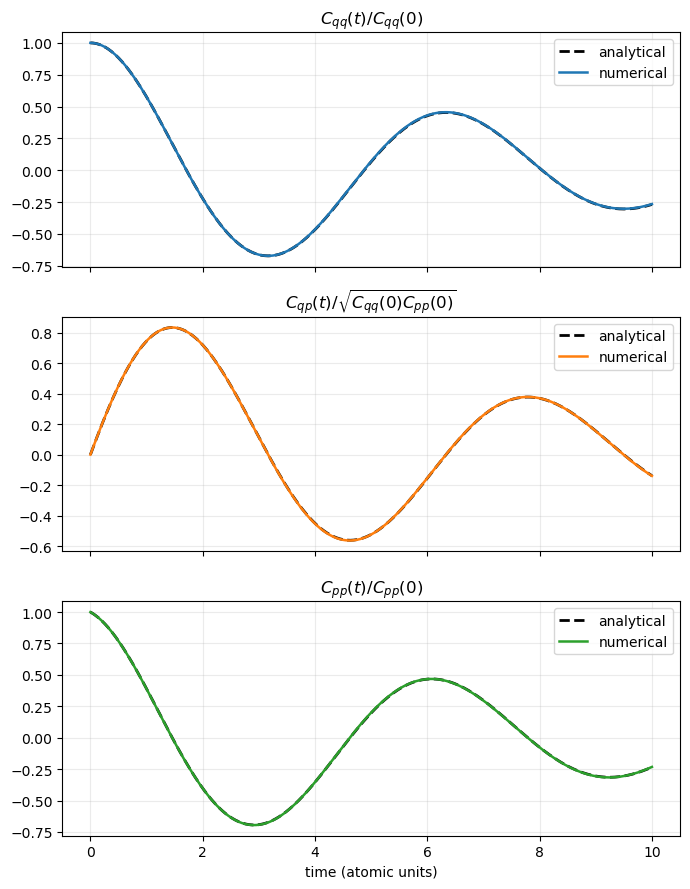

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)

axes[0].plot(t_ref, cqq_ref_n, color="black", ls="--", lw=2.0, label="analytical")
axes[0].plot(t_num, cqq_num_n, color="tab:blue", lw=1.8, label="numerical")
axes[0].set_title(r"$C_{qq}(t) / C_{qq}(0)$")

axes[1].plot(t_ref, cqp_ref_n, color="black", ls="--", lw=2.0, label="analytical")
axes[1].plot(t_num, cqp_num_n, color="tab:orange", lw=1.8, label="numerical")
axes[1].set_title(r"$C_{qp}(t) / \sqrt{C_{qq}(0) C_{pp}(0)}$")

axes[2].plot(t_ref, cpp_ref_n, color="black", ls="--", lw=2.0, label="analytical")
axes[2].plot(t_num, cpp_num_n, color="tab:green", lw=1.8, label="numerical")
axes[2].set_title(r"$C_{pp}(t) / C_{pp}(0)$")
axes[2].set_xlabel("time (atomic units)")

for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()

fig.tight_layout()
fig.savefig(ROOT / "george_numerical_vs_analytical_harmonic_tcf.png", dpi=200)
plt.show()

In [7]:
err_qq = np.sqrt(np.mean((np.interp(t_num, t_ref, cqq_ref_n) - cqq_num_n) ** 2))
err_qp = np.sqrt(np.mean((np.interp(t_num, t_ref, cqp_ref_n) - cqp_num_n) ** 2))
err_pp = np.sqrt(np.mean((np.interp(t_num, t_ref, cpp_ref_n) - cpp_num_n) ** 2))

with (ROOT / "george_numerical_vs_analytical_harmonic_tcf_errors.csv").open("w", newline="") as handle:
    writer = csv.writer(handle)
    writer.writerow(["dt_au", "burn_time", "trajectory_time", "n_replicas", "rms_cqq", "rms_cqp", "rms_cpp"])
    writer.writerow([dt, burn_time, trajectory_time, n_replicas, err_qq, err_qp, err_pp])

print("Wrote:", ROOT / "george_numerical_vs_analytical_harmonic_tcf.png")
print("Wrote:", ROOT / "george_numerical_vs_analytical_harmonic_tcf_errors.csv")
print()
print("RMS errors")
print("Cqq:", err_qq)
print("Cqp:", err_qp)
print("Cpp:", err_pp)

Wrote: /Users/u1865573/work/2026/friction-ipi/04_george_code_benchmark/ipi_harmonic_tcf_benchmark/george_numerical_vs_analytical_harmonic_tcf.png
Wrote: /Users/u1865573/work/2026/friction-ipi/04_george_code_benchmark/ipi_harmonic_tcf_benchmark/george_numerical_vs_analytical_harmonic_tcf_errors.csv

RMS errors
Cqq: 0.0018658794722363954
Cqp: 0.0013494941992672886
Cpp: 0.0013211847155641665
